### Dependencies

In [24]:
%pip install matplotlib
%pip install pyod
%pip install scikit-learn
%pip install scipy
%pip install combo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from pyod.utils.data import generate_data_clusters
from pyod.models.knn import KNN
from sklearn.metrics import balanced_accuracy_score
from sklearn.datasets import make_blobs
from pyod.models.lof import LOF
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pyod.utils.utility import standardizer
from pyod.models.combination import average
from pyod.models.combination import maximization
from mpl_toolkits.mplot3d import Axes3D

### Exercise 1

trace of H: 1.00 == num_dims: 1
trace of H: 1.00 == num_dims: 1
trace of H: 1.00 == num_dims: 1
trace of H: 1.00 == num_dims: 1


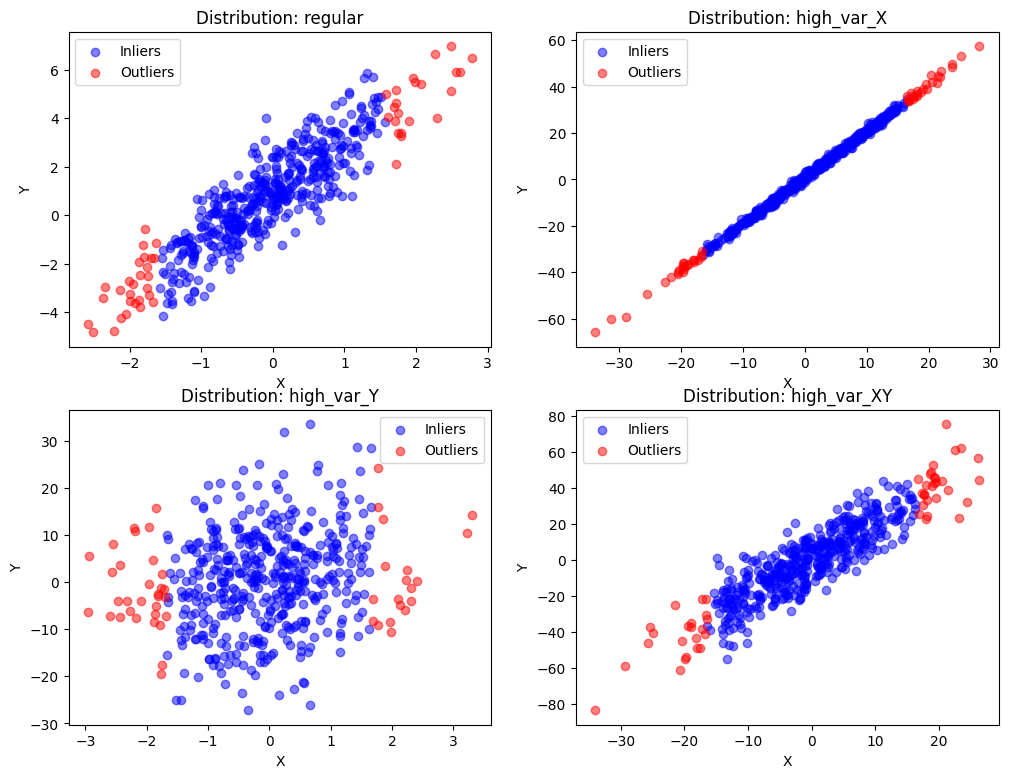

In [27]:
def ex1_1d():
    np.random.seed(23)

    num_samples = 500
    num_dims = 1

    a = 2.0
    b = 1.0

    miu = 0.0

    point_types = ['regular', 'high_var_X', 'high_var_Y', 'high_var_XY']
    _, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()
    for point_type, ax in zip(point_types, axes):
        if point_type == 'regular':
            var_eps = 1.0
            var_X = 1.0
        elif point_type == 'high_var_X':
            var_eps = 1.0
            var_X = 10.0
        elif point_type == 'high_var_Y':
            var_eps = 10.0
            var_X = 1.0
        else: # high_var_XY
            var_eps = 10.0
            var_X = 10.0

        eps = np.random.normal(miu, var_eps, (num_samples,))
        Xs = np.random.normal(miu, var_X, (num_samples, num_dims))
        Ys = (a * Xs + b).flatten() + eps

        H = Xs @ np.linalg.pinv(Xs)

        trace_H = np.trace(H)
        print(f'trace of H: {trace_H:.2f} == num_dims: {num_dims}')

        diag_H = np.diag(H)
        top_K = 50
        inlier_indices = np.argsort(-diag_H)[top_K:]
        outlier_indices = np.argsort(-diag_H)[:top_K]

        inlier_Xs = Xs[inlier_indices]
        inlier_Ys = Ys[inlier_indices]

        outlier_Xs = Xs[outlier_indices]
        outlier_Ys = Ys[outlier_indices]

        ax.scatter(inlier_Xs, inlier_Ys, c='blue', label='Inliers', alpha=0.5)
        ax.scatter(outlier_Xs, outlier_Ys, c='red', label='Outliers', alpha=0.5)
        ax.set_title(f'Distribution: {point_type}')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.legend()

    plt.show()


ex1_1d()

trace of H: 2.00 == num_dims: 2
trace of H: 2.00 == num_dims: 2
trace of H: 2.00 == num_dims: 2
trace of H: 2.00 == num_dims: 2


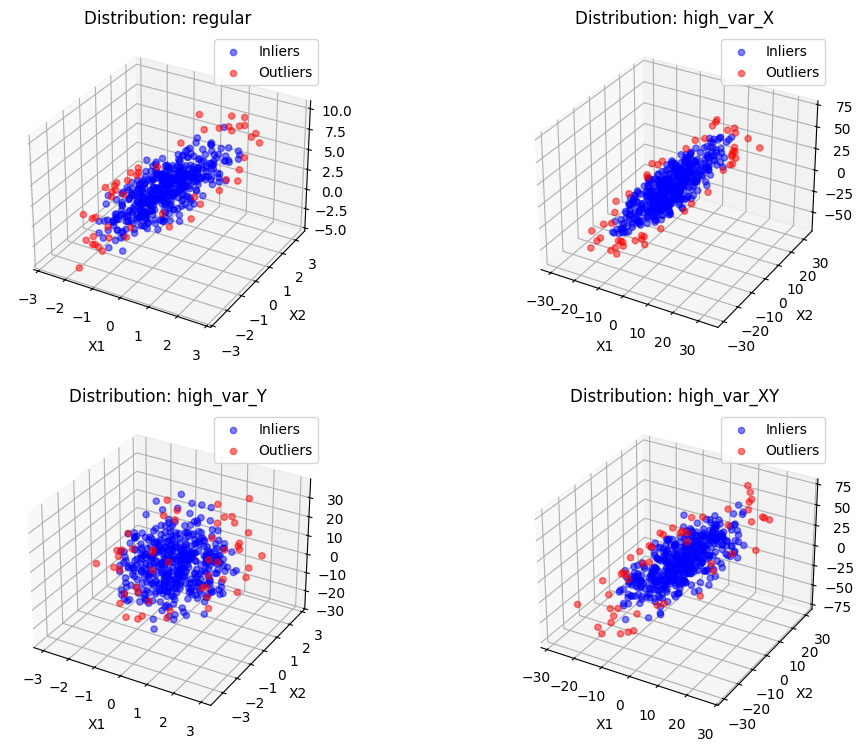

In [28]:
def ex1_2d():
    np.random.seed(23)

    num_samples = 500
    num_dims = 2

    a = 2.0
    b = 1.0
    c = 3.0

    miu = 0.0

    point_types = ['regular', 'high_var_X', 'high_var_Y', 'high_var_XY']
    fig = plt.figure(figsize=(12, 9))
    for idx, point_type in enumerate(point_types):
        ax = fig.add_subplot(2, 2, 1 + idx, projection='3d')

        if point_type == 'regular':
            var_eps = 1.0
            var_X = 1.0
        elif point_type == 'high_var_X':
            var_eps = 1.0
            var_X = 10.0
        elif point_type == 'high_var_Y':
            var_eps = 10.0
            var_X = 1.0
        else: # high_var_XY
            var_eps = 10.0
            var_X = 10.0

        eps = np.random.normal(miu, var_eps, (num_samples,))
        Xs = np.random.normal(miu, var_X, (num_samples, num_dims))
        Ys = a * Xs[:, 0] + b * Xs[:, 1] + c + eps

        H = Xs @ np.linalg.pinv(Xs)

        trace_H = np.trace(H)
        print(f'trace of H: {trace_H:.2f} == num_dims: {num_dims}')

        diag_H = np.diag(H)
        top_K = 50
        inlier_indices = np.argsort(-diag_H)[top_K:]
        outlier_indices = np.argsort(-diag_H)[:top_K]

        inlier_Xs = Xs[inlier_indices]
        inlier_Ys = Ys[inlier_indices]

        outlier_Xs = Xs[outlier_indices]
        outlier_Ys = Ys[outlier_indices]

        ax.scatter(inlier_Xs[:, 0], inlier_Xs[:, 1], inlier_Ys, c='blue', label='Inliers', alpha=0.5)
        ax.scatter(outlier_Xs[:, 0], outlier_Xs[:, 1], outlier_Ys, c='red', label='Outliers', alpha=0.5)
        ax.set_title(f'Distribution: {point_type}')
        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.legend()

    plt.show()


ex1_2d()

### Exercise 2

KNN with k=3: balanced_accuracy_train=0.96, balanced_accuracy_test=1.00


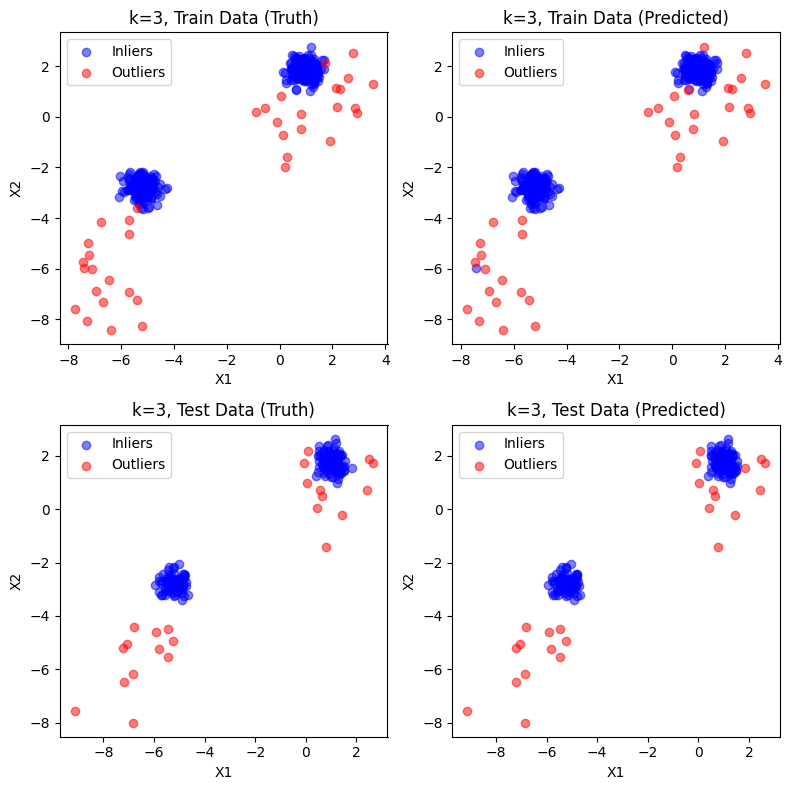

KNN with k=5: balanced_accuracy_train=0.97, balanced_accuracy_test=1.00


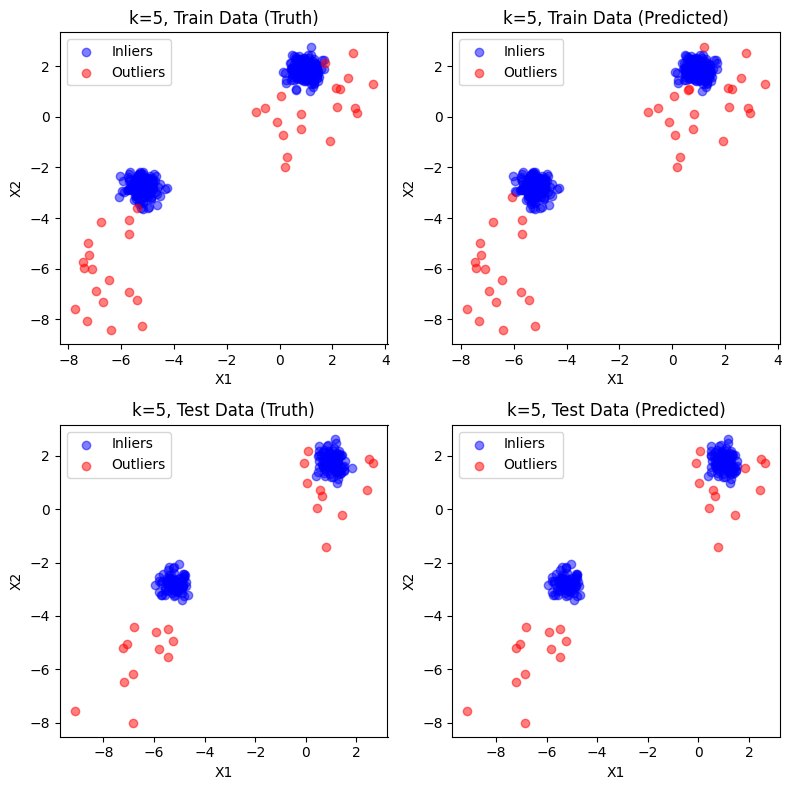

KNN with k=10: balanced_accuracy_train=0.97, balanced_accuracy_test=0.98


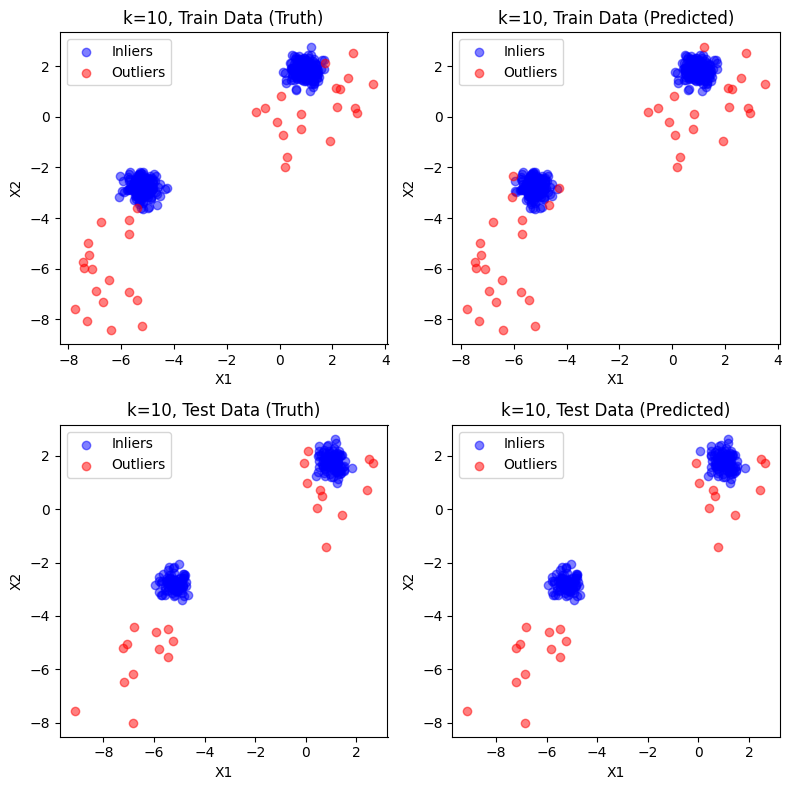

KNN with k=20: balanced_accuracy_train=0.97, balanced_accuracy_test=0.98


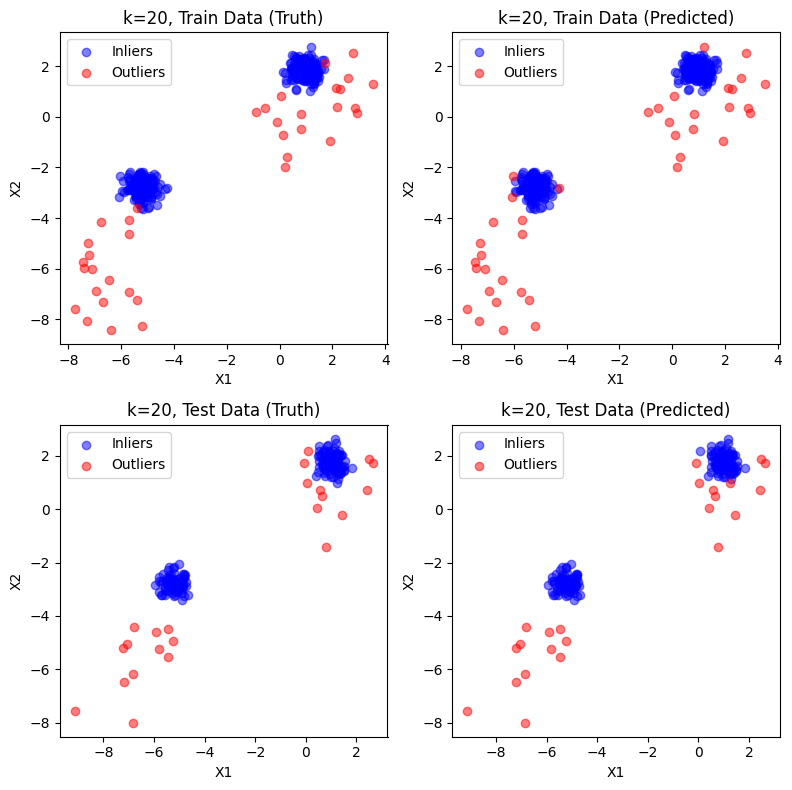

In [29]:
def ex2():
    X_train, X_test, Y_train, Y_test = generate_data_clusters(n_train=400, n_test=200, n_features=2, n_clusters=2, contamination=0.1, random_state=23)

    ks = [3, 5, 10, 20]
    for k in ks:
        knn = KNN(n_neighbors=k)
        knn.fit(X_train)

        Y_train_pred = knn.predict(X_train)
        Y_test_pred = knn.predict(X_test)

        balanced_accuracy_train = balanced_accuracy_score(Y_train, Y_train_pred)
        balanced_accuracy_test = balanced_accuracy_score(Y_test, Y_test_pred)

        print(f'KNN with k={k}: balanced_accuracy_train={balanced_accuracy_train:.2f}, balanced_accuracy_test={balanced_accuracy_test:.2f}')

        _, axes = plt.subplots(2, 2, figsize=(8, 8))
        axes = axes.flatten()

        axes[0].scatter(X_train[Y_train == 0][:, 0], X_train[Y_train == 0][:, 1], c='blue', label='Inliers', alpha=0.5)
        axes[0].scatter(X_train[Y_train == 1][:, 0], X_train[Y_train == 1][:, 1], c='red', label='Outliers', alpha=0.5)
        axes[0].set_title(f'k={k}, Train Data (Truth)')

        axes[1].scatter(X_train[Y_train_pred == 0][:, 0], X_train[Y_train_pred == 0][:, 1], c='blue', label='Inliers', alpha=0.5)
        axes[1].scatter(X_train[Y_train_pred == 1][:, 0], X_train[Y_train_pred == 1][:, 1], c='red', label='Outliers', alpha=0.5)
        axes[1].set_title(f'k={k}, Train Data (Predicted)')

        axes[2].scatter(X_test[Y_test == 0][:, 0], X_test[Y_test == 0][:, 1], c='blue', label='Inliers', alpha=0.5)
        axes[2].scatter(X_test[Y_test == 1][:, 0], X_test[Y_test == 1][:, 1], c='red', label='Outliers', alpha=0.5)
        axes[2].set_title(f'k={k}, Test Data (Truth)')

        axes[3].scatter(X_test[Y_test_pred == 0][:, 0], X_test[Y_test_pred == 0][:, 1], c='blue', label='Inliers', alpha=0.5)
        axes[3].scatter(X_test[Y_test_pred == 1][:, 0], X_test[Y_test_pred == 1][:, 1], c='red', label='Outliers', alpha=0.5)
        axes[3].set_title(f'k={k}, Test Data (Predicted)')

        for ax in axes:
            ax.set_xlabel('X1')
            ax.set_ylabel('X2')
            ax.legend()

        plt.tight_layout()
        plt.show()


ex2()

### Exercise 3

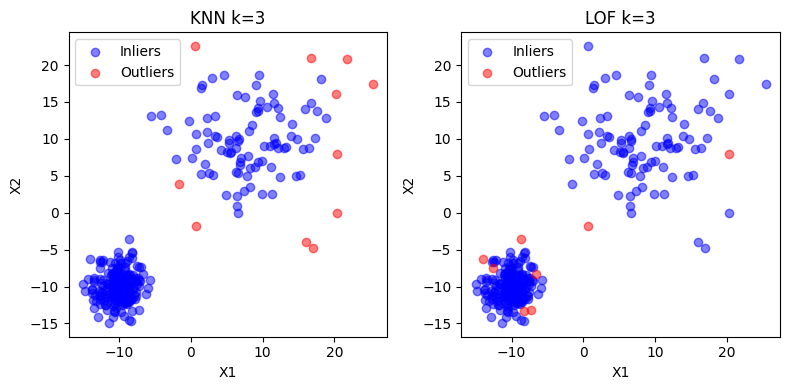

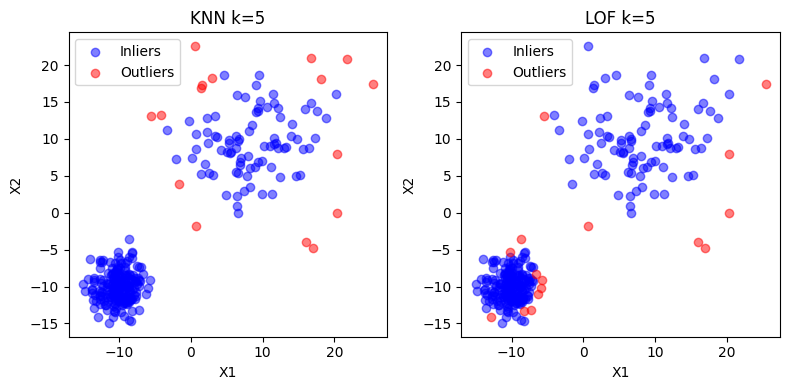

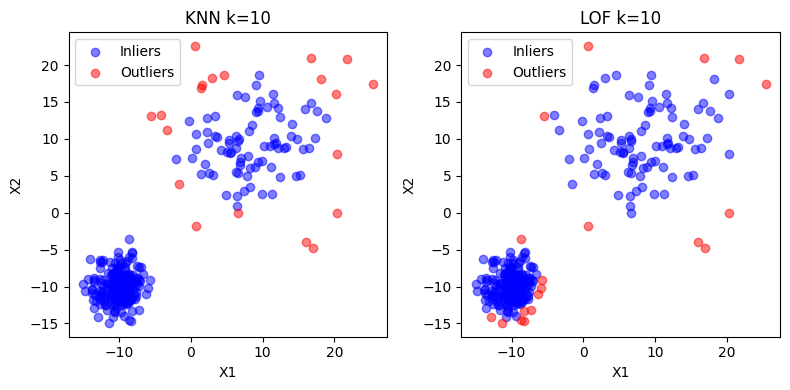

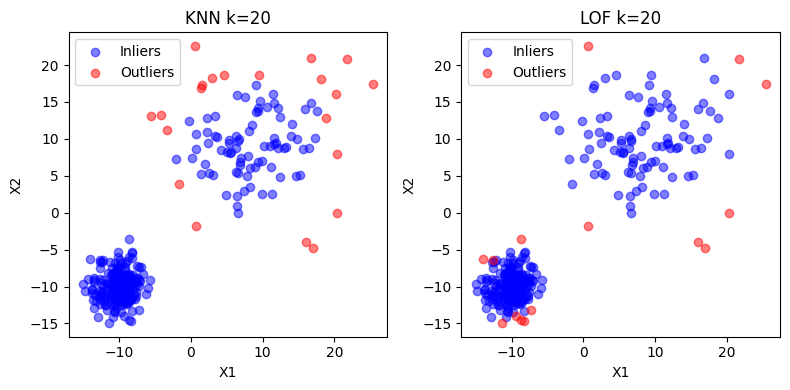

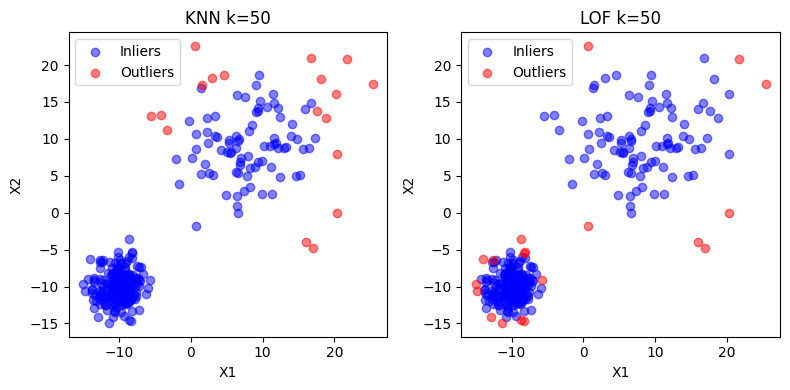

In [30]:
def ex3():
    X, Y = make_blobs(
        n_samples = [200, 100],
        n_features = 2,
        centers = [(-10.0, -10.0), (10.0, 10.0)],
        cluster_std = [2.0, 6.0],
        random_state = 23,
        shuffle = True
    )

    contamination = 0.07
    ks = [3, 5, 10, 20, 50]

    for k in ks:
        knn = KNN(n_neighbors=k, contamination=contamination)
        knn.fit(X)

        lof = LOF(n_neighbors=k, contamination=contamination)
        lof.fit(X)

        Y_pred_knn = knn.predict(X)
        Y_pred_lof = lof.predict(X)

        _, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes = axes.flatten()

        axes[0].scatter(X[Y_pred_knn == 0][:, 0], X[Y_pred_knn == 0][:, 1], c='blue', label='Inliers', alpha=0.5)
        axes[0].scatter(X[Y_pred_knn == 1][:, 0], X[Y_pred_knn == 1][:, 1], c='red', label='Outliers', alpha=0.5)
        axes[0].set_title(f'KNN k={k}')

        axes[1].scatter(X[Y_pred_lof == 0][:, 0], X[Y_pred_lof == 0][:, 1], c='blue', label='Inliers', alpha=0.5)
        axes[1].scatter(X[Y_pred_lof == 1][:, 0], X[Y_pred_lof == 1][:, 1], c='red', label='Outliers', alpha=0.5)
        axes[1].set_title(f'LOF k={k}')

        for ax in axes:
            ax.set_xlabel('X1')
            ax.set_ylabel('X2')
            ax.legend()

        plt.tight_layout()
        plt.show()


ex3()

### Exercise 4

In [ ]:
def ex4(model_name):
    cardio_mat = loadmat('cardio.mat')
    X = cardio_mat['X']
    Y = cardio_mat['y']

    contamination = np.sum(Y) / len(Y)

    test_size = 0.2
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=23)

    standard_scaler = StandardScaler()
    X_train = standard_scaler.fit_transform(X_train)
    X_test = standard_scaler.transform(X_test)

    num_models = 10
    ks = [30 + i * 10 for i in range(num_models)]
    if model_name == 'knn':
        models = [KNN(n_neighbors=k) for k in ks]
    elif model_name == 'lof':
        models = [LOF(n_neighbors=k) for k in ks]

    scores_train = []
    scores_test = []

    for k, model in zip(ks, models):
        model.fit(X_train)

        Y_train_pred = model.predict(X_train)
        Y_test_pred = model.predict(X_test)

        balanced_accuracy_train = balanced_accuracy_score(Y_train, Y_train_pred)
        balanced_accuracy_test = balanced_accuracy_score(Y_test, Y_test_pred)

        print(f'{model_name.upper()} with k={k}: balanced_accuracy_train={balanced_accuracy_train:.2f}, balanced_accuracy_test={balanced_accuracy_test:.2f}')

        scores_train.append(model.decision_function(X_train))
        scores_test.append(model.decision_function(X_test))

    scores_train = np.array(scores_train)
    scores_test = np.array(scores_test)

    scores_train = standardizer(scores_train.T)
    scores_test = standardizer(scores_test.T)

    average_scores_train = average(scores_train)
    average_scores_test = average(scores_test)

    maximum_scores_train = maximization(scores_train)
    maximum_scores_test = maximization(scores_test)

    average_threshold_train = np.quantile(average_scores_train, 1.0 - contamination)
    # average_threshold_test = np.quantile(average_scores_test, 1.0 - contamination)

    maximum_threshold_train = np.quantile(maximum_scores_train, 1.0 - contamination)
    # maximum_threshold_test = np.quantile(maximum_scores_test, 1.0 - contamination)

    Y_train_pred_average = (average_scores_train > average_threshold_train).astype(int)
    Y_test_pred_average = (average_scores_test > average_threshold_train).astype(int)

    Y_train_pred_maximum = (maximum_scores_train > maximum_threshold_train).astype(int)
    Y_test_pred_maximum = (maximum_scores_test > maximum_threshold_train).astype(int)

    balanced_accuracy_train_average = balanced_accuracy_score(Y_train, Y_train_pred_average)
    balanced_accuracy_test_average = balanced_accuracy_score(Y_test, Y_test_pred_average)

    balanced_accuracy_train_maximum = balanced_accuracy_score(Y_train, Y_train_pred_maximum)
    balanced_accuracy_test_maximum = balanced_accuracy_score(Y_test, Y_test_pred_maximum)

    print(f'{model_name.upper()}:')
    print(f'Ensemble: Train Average: {balanced_accuracy_train_average:.2f}, Test Average: {balanced_accuracy_test_average:.2f}')
    print(f'Ensemble: Train Maximum: {balanced_accuracy_train_maximum:.2f}, Test Maximum: {balanced_accuracy_test_maximum:.2f}')

    print()


ex4(model_name='knn')

ex4(model_name='lof')

KNN with k=30: balanced_accuracy_train=0.68, balanced_accuracy_test=0.72
KNN with k=40: balanced_accuracy_train=0.70, balanced_accuracy_test=0.71
KNN with k=50: balanced_accuracy_train=0.70, balanced_accuracy_test=0.73
KNN with k=60: balanced_accuracy_train=0.72, balanced_accuracy_test=0.72
KNN with k=70: balanced_accuracy_train=0.73, balanced_accuracy_test=0.74
KNN with k=80: balanced_accuracy_train=0.73, balanced_accuracy_test=0.75
KNN with k=90: balanced_accuracy_train=0.74, balanced_accuracy_test=0.75
KNN with k=100: balanced_accuracy_train=0.75, balanced_accuracy_test=0.78
KNN with k=110: balanced_accuracy_train=0.76, balanced_accuracy_test=0.78
KNN with k=120: balanced_accuracy_train=0.75, balanced_accuracy_test=0.78
KNN:
Ensemble: Train Average: 0.72, Test Average: 0.80
Ensemble: Train Maximum: 0.74, Test Maximum: 0.80

LOF with k=30: balanced_accuracy_train=0.54, balanced_accuracy_test=0.59
LOF with k=40: balanced_accuracy_train=0.54, balanced_accuracy_test=0.58
LOF with k=50: 